# Code to generate Figure 1 subplots

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import linregress

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

## Figure 1a,b

* create network graphs with NetworkX for the yeast two-hybrid and mass-spec interactomes

In [4]:
# paths to edge files with relative paths within the repo
f_ms_edges = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"
f_y2h_edges = f"{DATA_PATH1}Y2H_union-clean_edges.csv"

# read in edge files as pd.DataFrame objects
ms_edges = pd.read_csv(f_ms_edges)
y2h_edges = pd.read_csv(f_y2h_edges)

# reformat the "shared name" column in y2h_edges into "source" and "target" columns
y2h_edges[["source", "target"]] = y2h_edges["shared name"].str.split(" \(interacts with\) ", expand=True)

# create NetworkX graphs
ms_graph = nx.from_pandas_edgelist(ms_edges, "source", "target", create_using=nx.Graph())
y2h_graph = nx.from_pandas_edgelist(y2h_edges, "source", "target", create_using=nx.Graph())

# extract the largest connected subgraph
temp = max(nx.connected_components(ms_graph), key=len)
ms_conn = ms_graph.subgraph(temp).copy()
temp = max(nx.connected_components(y2h_graph), key=len)
y2h_conn = y2h_graph.subgraph(temp).copy()

# print some simple summary information
print (f"Number of nodes in MS graph: {ms_graph.number_of_nodes()}")
print (f"Number of edges in MS graph: {ms_graph.number_of_edges()}")
print (f"Number of nodes in largest connected MS graph: {ms_conn.number_of_nodes()}")
print (f"Number of edges in largest connected MS graph: {ms_conn.number_of_edges()}")
print (f"\nNumber of nodes in Y2H graph: {y2h_graph.number_of_nodes()}")
print (f"Number of edges in Y2H graph: {y2h_graph.number_of_edges()}")
print (f"Number of nodes in largest connected Y2H graph: {y2h_conn.number_of_nodes()}")
print (f"Number of edges in largest connected Y2H graph: {y2h_conn.number_of_edges()}")

Number of nodes in MS graph: 3927
Number of edges in MS graph: 31004
Number of nodes in largest connected MS graph: 3839
Number of edges in largest connected MS graph: 30955

Number of nodes in Y2H graph: 2018
Number of edges in Y2H graph: 2930
Number of nodes in largest connected Y2H graph: 1647
Number of edges in largest connected Y2H graph: 2682


* these numbers exactly match expectation based on:
    * MS: Figure 3d [here](https://www.nature.com/articles/s41586-023-06739-5/figures/3)
    * Y2H: data summary for Y2H-union [here](https://interactome.dfci.harvard.edu/S_cerevisiae/index.php?page=download)
* we can proceed to make the network graph images 

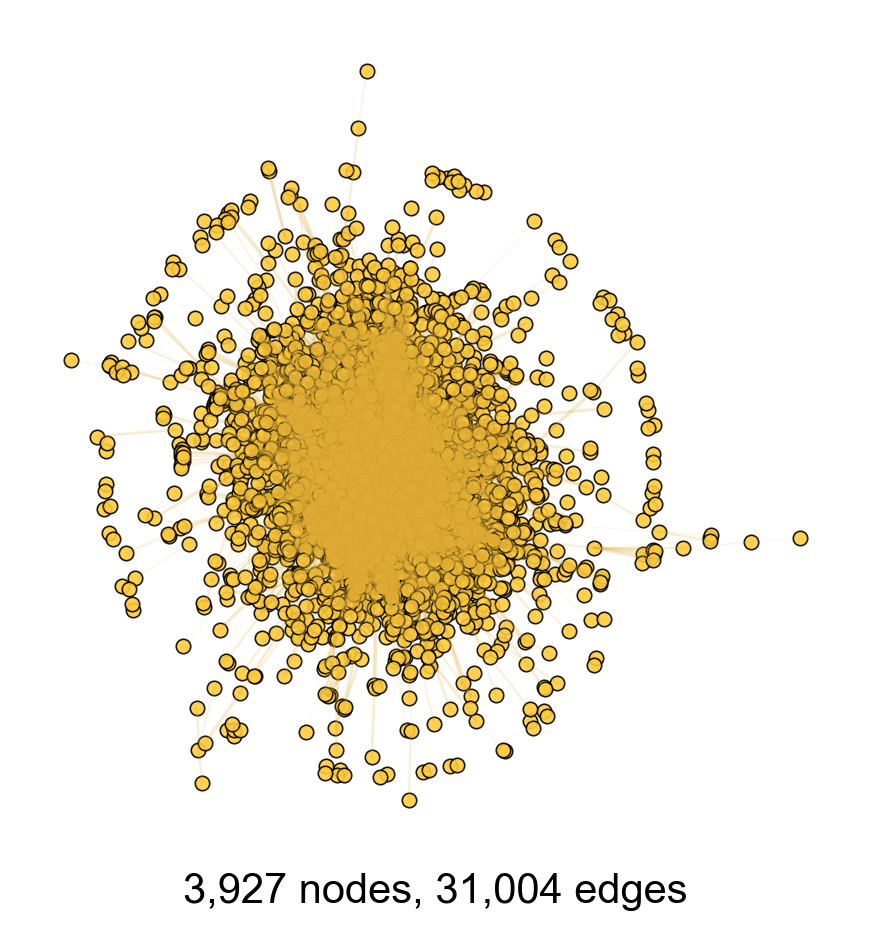

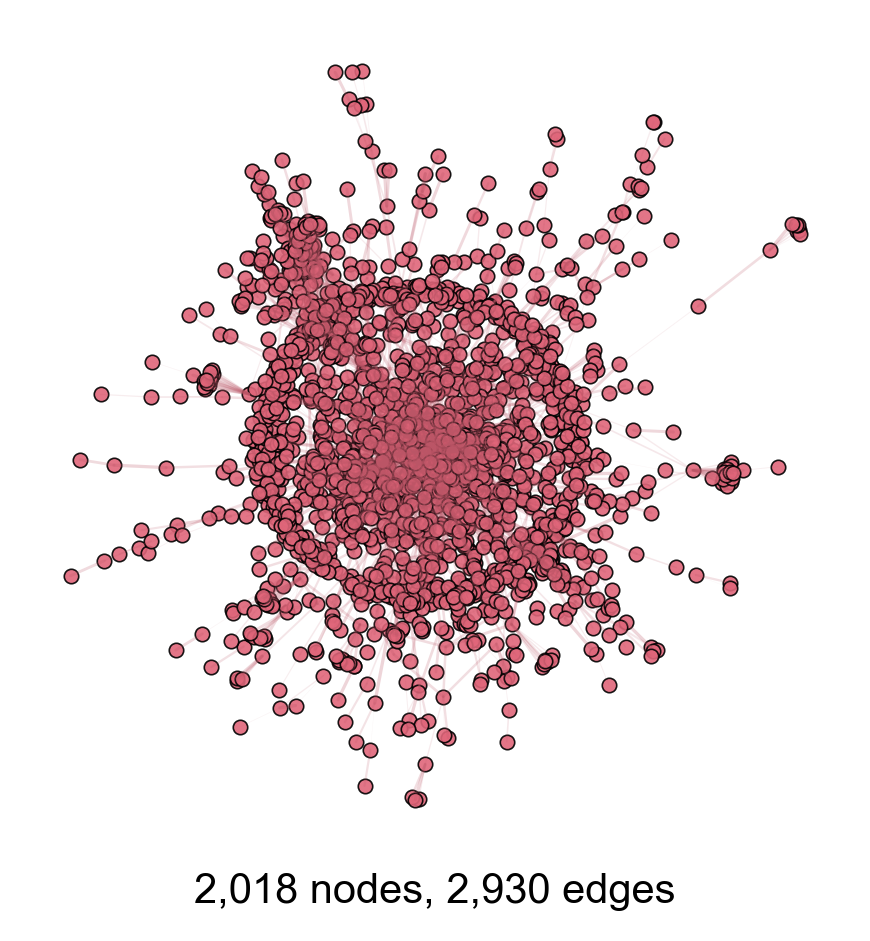

In [8]:
import matplotlib.colors as mcolors
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

def plot_high_quality_network2(
    G,
    title,
    color,
    save_name,
    legend_label,
    node_size=12,
    component_compression=0.4,
    border_frac=0.05,  # fraction of width/height to use as padding
    k=0.2
):
    fig, ax = plt.subplots(figsize=(3, 3))

    # --- ADD COLOR VARIANTS HERE ---
    base_color = mcolors.to_rgb(color)
    dark_color = tuple(np.clip(np.array(base_color) * 0.7, 0, 1))
    bright_color = tuple(np.clip(np.array(base_color) * 1.2, 0, 1))

    # --- 1. Base layout ---
    pos = nx.spring_layout(G, seed=42, k=k, iterations=100)

    # --- 2. Component compression (unchanged) ---
    G_und = G if not G.is_directed() else G.to_undirected()
    components = list(nx.connected_components(G_und))

    node_to_comp = {}
    for cid, comp in enumerate(components):
        for n in comp:
            node_to_comp[n] = cid

    comp_centroids = {}
    for cid, comp in enumerate(components):
        xs = [pos[n][0] for n in comp]
        ys = [pos[n][1] for n in comp]
        comp_centroids[cid] = np.array([np.mean(xs), np.mean(ys)])

    all_centroids = np.vstack(list(comp_centroids.values()))
    global_centroid = all_centroids.mean(axis=0)

    f = component_compression

    new_pos = {}
    for cid, comp in enumerate(components):
        old_centroid = comp_centroids[cid]
        new_centroid = global_centroid + f * (old_centroid - global_centroid)
        shift = new_centroid - old_centroid
        for n in comp:
            new_pos[n] = pos[n] + shift

    pos = new_pos

    # --- 3. Normalize AND add border padding in data space ---
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()
    span_x = max_x - min_x if max_x > min_x else 1.0
    span_y = max_y - min_y if max_y > min_y else 1.0

    # map into [border_frac, 1 - border_frac] instead of [0, 1]
    inner_scale_x = 1 - 2 * border_frac
    inner_scale_y = 1 - 2 * border_frac

    for n in pos:
        x, y = pos[n]
        x_norm = (x - min_x) / span_x
        y_norm = (y - min_y) / span_y
        pos[n] = (
            border_frac + inner_scale_x * x_norm,
            border_frac + inner_scale_y * y_norm,
        )

    # --- 4. Draw edges ---
    edges = np.array(list(G.edges()))
    np.random.shuffle(edges)
    n_edges = len(edges)
    alphas = np.linspace(0.05, 0.25, n_edges)
    widths = np.linspace(0.1, 0.8, n_edges)

    for i, (u, v) in enumerate(edges):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot(
            [x0, x1],
            [y0, y1],
            color=color,
            lw=widths[i],
            alpha=alphas[i],
            solid_capstyle="round",
            zorder=i,
        )

    # --- 5. Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_size,
        node_color=bright_color,
        alpha=0.9,
        linewidths=0.4,
        edgecolors='black'
    )


    # --- 6. Axes settings: include the padding region ---
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    if title:
        ax.set_title(title)

    fig.text(
        0.5,
        -0.02,
        f"{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges",
        ha="center",
        fontsize=10,
    )

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches="tight", facecolor="white")
    plt.show()

# plot MS network
plot_high_quality_network2(
    ms_graph,
    title=f"",
    color=MS_COLOR,
    save_name="1a.svg",
    legend_label="",
    component_compression=0.5,
    k=0.2
)


# plot Y2H network
plot_high_quality_network2(
    y2h_graph,
    title=f"",
    color=Y2H_COLOR,
    save_name="1b.svg",
    legend_label="",
    component_compression=0.4,
    k=0.2
)

## Figure 1c

* plot empirical cumulative distribution functions (CDFs) of degree centrality for nodes in MS and Y2H data.

/var/folders/z7/zgkyq53d7z59nk3r91kprvj40000gp/T/ipykernel_13002/3382288545.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=10)


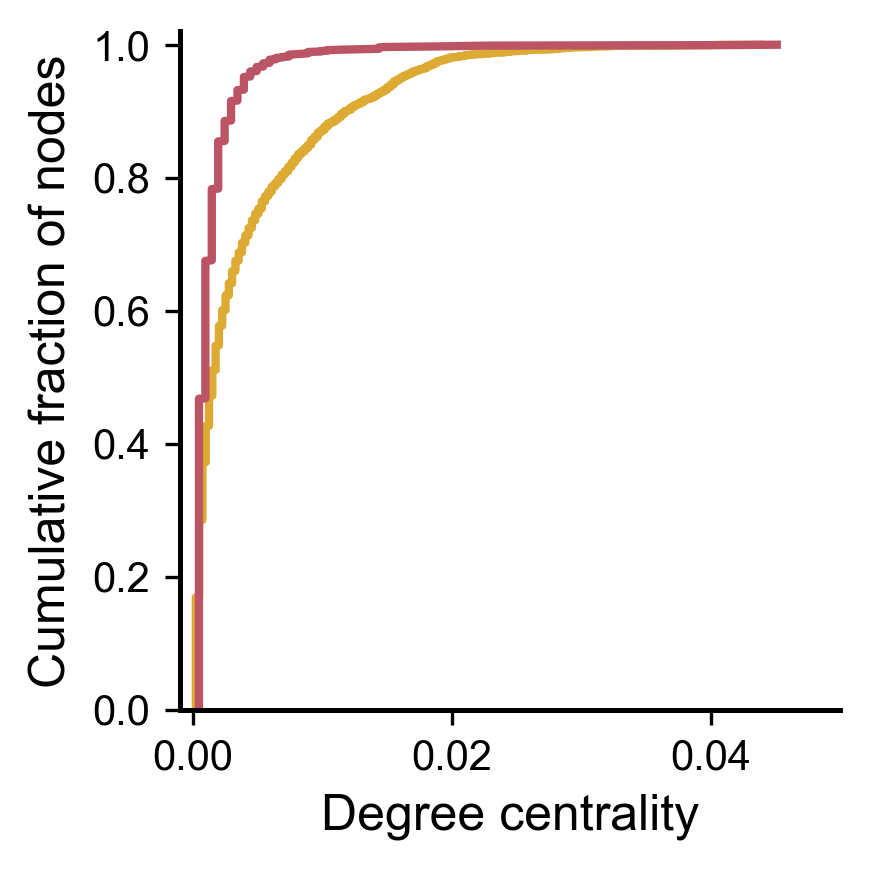

In [9]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20251209-s288c-annotated-PPI-net.pkl")

# Extract degree centrality values and drop NaNs
ms_deg  = nodes["degree_centrality"].dropna().values
y2h_deg = nodes["Y2H_degree_centrality"].dropna().values

# Sort values for CDF
ms_sorted  = np.sort(ms_deg)
y2h_sorted = np.sort(y2h_deg)

# Empirical CDFs
ms_cdf  = np.arange(1, len(ms_sorted) + 1) / len(ms_sorted)
y2h_cdf = np.arange(1, len(y2h_sorted) + 1) / len(y2h_sorted)

# Plot
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(
    ms_sorted,
    ms_cdf,
    color=MS_COLOR,
    linewidth=2,
    label=""
)

ax.plot(
    y2h_sorted,
    y2h_cdf,
    color=Y2H_COLOR,
    linewidth=2,
    label=""
)

# Labels
ax.set_xlabel("Degree centrality", fontsize=12)
ax.set_ylabel("Cumulative fraction of nodes", fontsize=12)

# Axis styling
ax.set_xlim(-0.001, 0.05)
ax.set_ylim(0, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.grid(False)

ax.tick_params(axis="both", labelsize=10)

# Legend
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("1c.svg")
plt.show()

## Figure 1d

* plot the node degree distributions for the mass spec and Y2H data

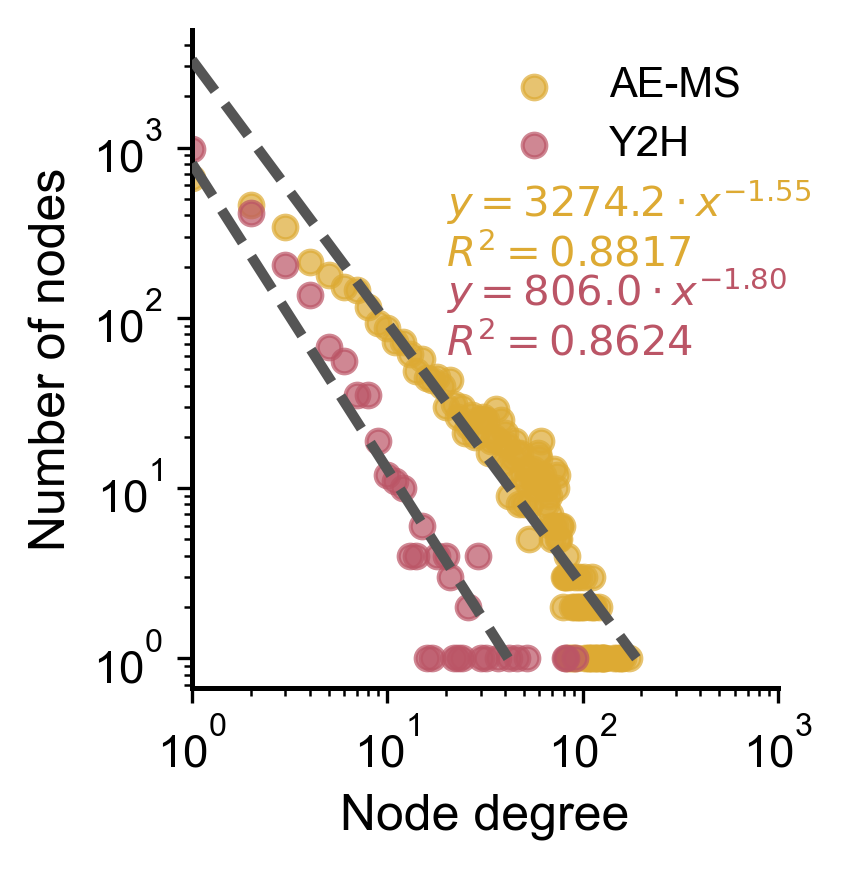

In [10]:
# helper function to compute degree distribution
def compute_degree_distribution(source_nodes, target_nodes):
    all_nodes = pd.concat([pd.Series(source_nodes), pd.Series(target_nodes)])
    degree_counts = all_nodes.value_counts().sort_index()
    unique_degrees, counts = np.unique(degree_counts.values, return_counts=True)
    return unique_degrees, counts

# helper function to perform power law fitting
def powerlaw_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    return slope, intercept, r_value**2, x

# helper function to perform exponential fitting
def exponential_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_y = np.log(y)
    slope, intercept, r_value, p_value, std_err = linregress(x, log_y)
    a = np.exp(intercept)
    b = slope
    return a, b, r_value**2, x

### PERFORM FITTING

# compute degrees and counts for MS and Y2H networks
ms_degrees, ms_counts   = compute_degree_distribution(ms_edges['source'], ms_edges['target'])
y2h_degrees, y2h_counts = compute_degree_distribution(y2h_edges["source"], y2h_edges["target"])

# fit power law to MS data
slope_ms, intercept_ms, R2_ms, x_fit_ms = powerlaw_fit(ms_degrees, ms_counts, fit_range=None)
x_start_ms = 1
x_end_ms = 10 ** (-intercept_ms / slope_ms)
x_plot_ms = np.linspace(np.log10(x_start_ms), np.log10(x_end_ms), 100)
y_plot_ms = slope_ms * x_plot_ms + intercept_ms
eqn_str_ms = f"$y = {10**intercept_ms:.1f} \\cdot x^{{{slope_ms:.2f}}}$\n$R^2 = {R2_ms:.4f}$"

# fit power law to Y2H data
slope_y2h, intercept_y2h, R2_y2h, x_fit_y2h = powerlaw_fit(y2h_degrees, y2h_counts, fit_range=None)
x_start_y2h = 1
x_end_y2h = 10 ** (-intercept_y2h / slope_y2h)
x_plot_y2h = np.linspace(np.log10(x_start_y2h), np.log10(x_end_y2h), 100)
y_plot_y2h = slope_y2h * x_plot_y2h + intercept_y2h
eqn_str_y2h = f"$y = {10**intercept_y2h:.1f} \\cdot x^{{{slope_y2h:.2f}}}$\n$R^2 = {R2_y2h:.4f}$"

### GENERATE PLOT

fig, ax = plt.subplots(figsize=(3, 3))

# plot the actual data
ax.scatter(ms_degrees, ms_counts, s=32, color=MS_COLOR, zorder=2, label='AE-MS', alpha=0.7)
ax.scatter(y2h_degrees, y2h_counts, s=32, color=Y2H_COLOR, zorder=2, label='Y2H', alpha=0.7)

# plot the fits
ax.plot(10**x_plot_ms, 10**y_plot_ms, '--', color='#555555', lw=2.5, zorder=3)
ax.plot(10**x_plot_y2h, 10**y_plot_y2h, '--', color='#555555', lw=2.5, zorder=3)

# add equation annotations
ax.annotate(eqn_str_ms, xy=(20, 200), fontsize=10, fontfamily='Arial', color=MS_COLOR, zorder=10, fontweight='bold')
ax.annotate(eqn_str_y2h, xy=(20, 60), fontsize=10, fontfamily='Arial', color=Y2H_COLOR, zorder=10, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Node degree', color='black', fontsize=12)
ax.set_ylabel('Number of nodes', color='black', fontsize=12)
ax.tick_params(axis='both', labelsize=11, colors='black')
ax.legend(loc='upper right', fontsize=10, frameon=False)

fig.tight_layout()

# --- Clean spines (Origin style) ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.xlim(1, 1000)

# --- Save and/or show ---
fig.savefig("1d.svg", dpi=300, bbox_inches='tight')
plt.show()

### Figure 1e

* compute the Jaccard similarity between the hubs in the two networks
* hubs are defined based on a degree centrality percentile cutoff

In [11]:
# we have ms_edges and y2h_edges from the first cell of this notebook

# load the datasets with node centrality information and get nodes in both
ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")

# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = ms_nodes["degree_centrality"].quantile(1 - cut)
y2h_threshold = y2h_nodes["degree_centrality"].quantile(1 - cut)
ms_hubs = ms_nodes[ms_nodes["degree_centrality"] >= ms_threshold]
y2h_hubs = y2h_nodes[y2h_nodes["degree_centrality"] >= y2h_threshold]
print (f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs")
print (f"Threshold for defining a hub in Y2H datais {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs")

# count the shared hubs
shared_hubs = set(ms_hubs["node"]) & set(y2h_hubs["node"])
all_hubs = set(ms_hubs["node"]) | set(y2h_hubs["node"])
print (f"A total of {len(shared_hubs)} hubs are shared between the MS and Y2H networks")
print (f"In total, we have {len(all_hubs)} unique hubs")

# compute the Jaccard similarity
jaccard_hubs = len(shared_hubs) / len(all_hubs)
print(f"Jaccard similarity between MS and Y2H hubs = {jaccard_hubs:.4f}")

A total of 1465 nodes are shared between the MS and Y2H networks
Threshold for defining a hub in MS data is 0.01182; there are 393 hubs
Threshold for defining a hub in Y2H datais 0.00297; there are 223 hubs
A total of 6 hubs are shared between the MS and Y2H networks
In total, we have 610 unique hubs
Jaccard similarity between MS and Y2H hubs = 0.0098


MS graph (shared):  1269 nodes, 3942 edges
Y2H graph (shared): 1288 nodes, 1557 edges

=== Hub connectivity Jaccard similarity ===
Number of unique hubs: 610
Mean Jaccard (all hubs):        0.0308
Mean Jaccard (shared hubs only): 0.0856

Hubs with Jaccard >= 0.3: 11
Example high-overlap hubs: ['YBR135W', 'YDR328C', 'YEL015W', 'YIL033C', 'YJR102C']


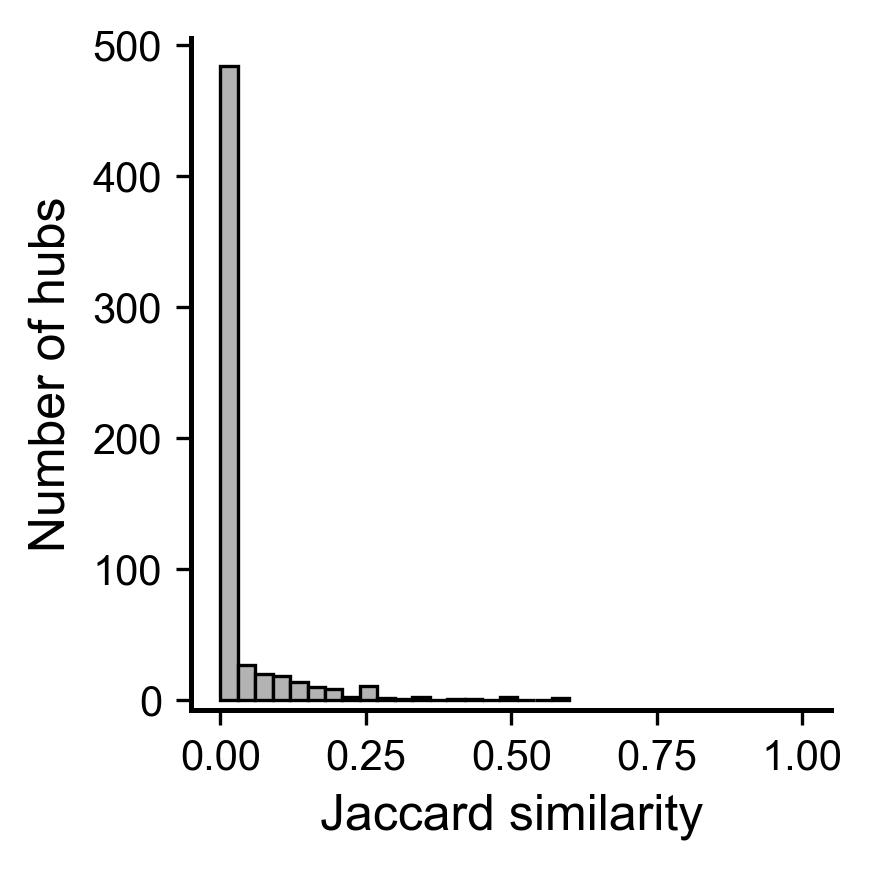

In [12]:
# filter to edges whose endpoints are in shared_nodes and are not self-loops
ms_edges_shared = (
    ms_edges.query("source in @shared_nodes and target in @shared_nodes and source != target")
             [["source", "target"]]
)

y2h_edges_shared = (
    y2h_edges.query("source in @shared_nodes and target in @shared_nodes and source != target")
              [["source", "target"]]
)

# create networkx graphs of the shared edge networks only
G_ms = nx.from_pandas_edgelist(ms_edges_shared, source="source", target="target")
G_y2h = nx.from_pandas_edgelist(y2h_edges_shared, source="source", target="target")

print(f"MS graph (shared):  {G_ms.number_of_nodes()} nodes, {G_ms.number_of_edges()} edges")
print(f"Y2H graph (shared): {G_y2h.number_of_nodes()} nodes, {G_y2h.number_of_edges()} edges")

def jaccard_neighbors(G1: nx.Graph, G2: nx.Graph, node: str) -> float:
    """Jaccard similarity between neighbor sets of `node` in two graphs."""
    # if node is missing from both, define similarity as 0
    if node not in G1 and node not in G2:
        return 0.0

    neighbors1 = set(G1.neighbors(node)) if node in G1 else set()
    neighbors2 = set(G2.neighbors(node)) if node in G2 else set()

    inter = neighbors1 & neighbors2
    union = neighbors1 | neighbors2
    return len(inter) / len(union) if union else 0.0

# compute Jaccard connectivity similarity for all hubs
ms_hub_set = set(ms_hubs["node"])
y2h_hub_set = set(y2h_hubs["node"])

records = []
for node in sorted(all_hubs):
    jacc = jaccard_neighbors(G_ms, G_y2h, node)
    records.append({
        "node": node,
        "jaccard_neighbors": jacc,
        "is_ms_hub": node in ms_hub_set,
        "is_y2h_hub": node in y2h_hub_set,
        "is_shared_hub": node in shared_hubs,
    })

hub_conn_df = pd.DataFrame(records)

# summary statistics

overall_mean = hub_conn_df["jaccard_neighbors"].mean()
shared_mean = hub_conn_df.loc[hub_conn_df["is_shared_hub"], "jaccard_neighbors"].mean()

print("\n=== Hub connectivity Jaccard similarity ===")
print(f"Number of unique hubs: {len(all_hubs)}")
print(f"Mean Jaccard (all hubs):        {overall_mean:.4f}")
print(f"Mean Jaccard (shared hubs only): {shared_mean:.4f}")

# classify “similar” hubs by a threshold
jaccard_threshold = 0.3
similar_hubs = hub_conn_df[hub_conn_df["jaccard_neighbors"] >= jaccard_threshold]

print(f"\nHubs with Jaccard >= {jaccard_threshold}: {len(similar_hubs)}")
print("Example high-overlap hubs:", similar_hubs["node"].head().tolist())

# histogram of hub connectivity overlap
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(
    hub_conn_df["jaccard_neighbors"],
    bins=20,
    color="0.7",        # grey fill
    edgecolor="black",  # black outline
    linewidth=0.8,      # thin but visible
)

ax.set_xlabel("Jaccard similarity", fontsize=12)
ax.set_ylabel("Number of hubs", fontsize=12)
#ax.set_title("Hub connectivity overlap")
ax.grid(False)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Make bars go down to the x-axis (y = 0)
ax.set_ylim(-7, 505)      # lower bound at 0 instead of -5
ax.set_xlim(-0.05, 1.05)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

plt.tight_layout()
plt.savefig("1e.svg")
plt.show()